# **The 6-step Data Quality Method**
## https://github.com/royruddle/6-step-data-quality-method

This is the notebook that is used in the YouTube video about **Step 2** of the method (https://www.youtube.com/watch?v=ibY5oAvSC-w), and shows how to use the vizdataquality package to investigate data quality.

The 6 steps are:
1. Is anything obviously wrong?
2. Watch out for special values
3. Is any data missing?
4. Check each variable
5. Check combinations of variables
6. Profile the cleaned data

## **Step 2: Watch out for special values**

- Special values that are documented
- Widely used special values
- Text values in a numerical column
- Large positive/negative integers or very old dates
- Default values

### Includes: vizdataquality and other libraries

In [1]:
import os
import pandas as pd

from vizdataquality import calculate as vdqc, plot as vdqp

### (a) Special values that are documented

In this example the dataset contains machine-readable documentation, which may be loaded as a dataframe. The documentation (https://assets.publishing.service.gov.uk/media/691c6440e39a085bda43eed6/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx) is part of the UK Government Road Safety Open Data. It is licensed under the terms of the Open Government Licence (https://www.nationalarchives.gov.uk/doc/open-government-licence/version/3/).

#### Find labels that contain the word 'missing'

In [2]:
folder = '../../examples'
input_filename = os.path.join(folder, 'dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx')
xlsx = pd.ExcelFile(input_filename)
df_doc = pd.read_excel(xlsx, sheet_name='2024_code_list')

special_values = set()
# Loop over the values in this column
for item in df_doc['label'].dropna().unique():
    lowercase = str(item).lower()
    
    if 'missing' in lowercase:
        special_values.add(item)

print('Missing values:', special_values)

Missing values: {'Data missing or out of range'}


#### Find labels that contain the word 'unknown'

In [3]:
special_values = set()
# Loop over the values in this column
for item in df_doc['label'].dropna().unique():
    lowercase = str(item).lower()
    
    if 'unknown' in lowercase:
        special_values.add(item)

print('UNKNOWN VALUES:')
for item in special_values:
    print(item)      

UNKNOWN VALUES:
Motorcycle - unknown cc
Unknown vehicle type (self rep only)
Unknown (self rep only)
Darkness - lighting unknown
Unknown or other
unknown (self reported)
Motorcycle - unknown cc rider or passenger
Goods vehicle - unknown weight
Goods vehicle (unknown weight) occupant
Unknown


### (b) Widely used special values

This example uses a dataset about bus stops (https://datamillnorth.org/dataset/bus-stops-20z59), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence.

#### Pandas defaults

The pandas.read_csv() documentation says "By default the following values are interpreted as NaN: empty string, “NaN”, “N/A”, “NULL”, and other common representations of missing data."

In [4]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Bus%20stops%20NT%20%26%20NC.csv')

# Read the dataset, but only treat empty cells as missing values
df_blankcells = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False, low_memory=False)
# Use the Pandas defaults for missing values
df_defaultspecials = pd.read_csv(input_filename, encoding='ascii', low_memory=False)

# Call vizdataquality to find out what defaults were used
special_values = vdqc.get_df_extra_values(df_blankcells, df_defaultspecials, convert_numbers=True)
print('Pandas changed these values to missing:', special_values)

Pandas changed these values to missing: {'None'}


#### What similar values did Pandas leave unchanged?

In [5]:
other_none = set()
none_columns = set()

for col in df_defaultspecials.columns:
    for item in df_defaultspecials[col].unique():
        if str(item).lower().strip() == 'none':
            other_none.add(item)
            none_columns.add(col)

print("The following columns contained the word 'None':", none_columns)
print('But Pandas did not treat these capitalisations as missing', other_none.difference(special_values))

The following columns contained the word 'None': {'Casetype', 'Plate_loca', 'Lighting', 'Shelter_Ty'}
But Pandas did not treat these capitalisations as missing {'none', 'NONE', 'NOne'}


### (c) Text values in a numerical column

This example uses a dataset about leakage from water supplies (https://datamillnorth.org/dataset/leakage-vqx64), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence.

In [6]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Performance%20Commitment%205%20-%20Leakage%20converted.csv')

# Read the dataset, but only treat empty cells as missing values
df_blankcells = pd.read_csv(input_filename, encoding='UTF-8-SIG', na_values='', keep_default_na=False, low_memory=False)
print(df_blankcells.dtypes)

Distribution metering area     object
Latitude                       object
Longitude                      object
Area Name                      object
Ownership area                 object
Functional Area                object
Apr-18                        float64
May-18                        float64
Jun-18                        float64
Jul-18                        float64
Aug-18                        float64
Sep-18                        float64
Oct-18                        float64
Nov-18                        float64
Dec-18                        float64
Jan-19                        float64
Feb-19                        float64
Mar-19                        float64
dtype: object


#### Why are Latitude and Longitude 'object' not 'float64'?

In [7]:
non_numerical_values = vdqc.get_non_numeric_values(pd.DataFrame(df_blankcells[['Latitude', 'Longitude']]), convert_numbers=True)
print('Non-numerical values in the Latitude and Longitude columns:', non_numerical_values)

Non-numerical values in the Latitude and Longitude columns: ['#N/A', 'Top end additions']


### (d) Large positive/negative integers or very old dates

This example uses a year's worth (20 million records) of admitted patient care episodes in English hospitals (NHS Digital data agreement NIC-49164-R3G5K). The data was processed to extract unique values for three variables.  Those values were then replaced by simulated values, which are realistic.

In [8]:
folder = '../../examples'
#input_filename = os.path.join(folder, 'APC_unique_values_ADMIAGE_ADMISORC_EPIORDER.csv')
input_filename = os.path.join(folder, 'APC_simulated_unique_values.csv')

# Read the dataset, only treating empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False, low_memory=False)

The data dictionary states:
- ADMIAGE values are the patient's age or 999 (not known)

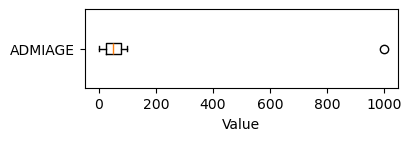

In [9]:
fig_kw = {'size_inches': (4, 1.3), 'constrained_layout': True}
ax_kw = {'ylabel': None}
vdqp.boxplot_raw(df[['ADMIAGE']], vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

The data dictionary states:
- Normal ADMISORC values are 29 - 89 (a lookup table). Special values are 98 (not applicable) and 99 (not known)
- Normal EPIORDER values are 1 - 87. Special values are 98 (not applicable) and 99 (not known)

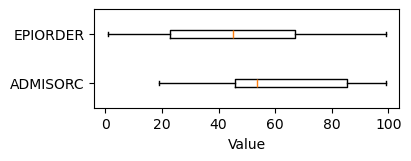

In [10]:
fig_kw = {'size_inches': (4, 1.5), 'constrained_layout': True}
ax_kw = {'ylabel': None}
vdqp.boxplot_raw(df[['ADMISORC', 'EPIORDER']], vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

### (e) Default values

This example uses a dataset about water meter readings (https://datamillnorth.org/dataset/domestic-consumption-monitor-monthly-meter-readings-e51j7), (c) Leeds City Council, 2026. The data is licensed under the terms of the Open Government Licence.

In [11]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Domestic%20Consumption%20Monitor%20monthly%20meter%20readings%202010-2015.csv')

# Read the dataset, only treating empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False, low_memory=False)

#### Is '0' a real value or missing data?

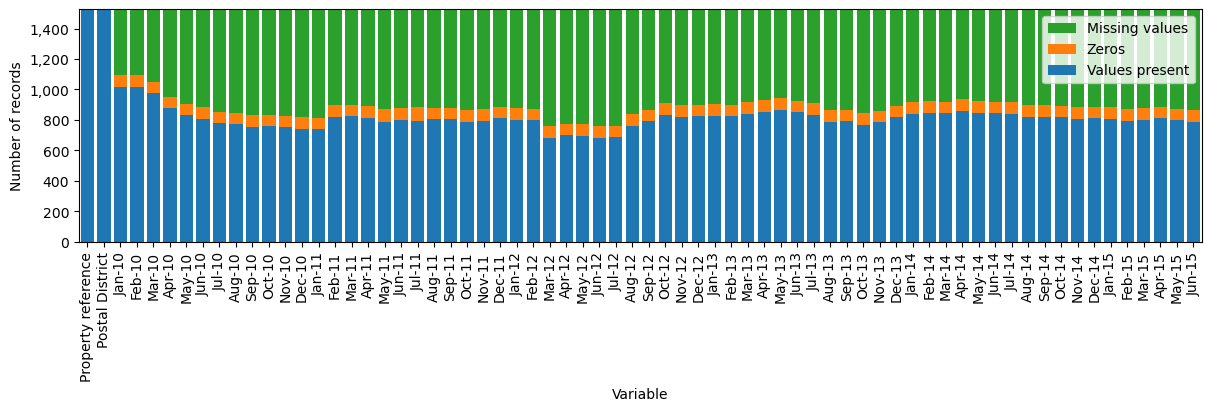

In [12]:
# Calculate some statistics about each column
column_stats = vdqc.calc(df)
df_step2 = pd.DataFrame([column_stats['Number of values'].values, column_stats['Number of zero values'].values,
                         column_stats['Number of missing values'].values], index=['Values present', 'Zeros', 'Missing values'],
                        columns=column_stats.index)
fig_kw = {'size_inches': (12, 4), 'constrained_layout': True}
ax_kw = {'ylim': (0, len(df)), 'ylabel': 'Number of records'}
legend_kw = {'reverse': True}
vdqp.stacked_bar(df_step2, xlabels_rotate=90, fig_kw=fig_kw, ax_kw=ax_kw, legend_kw=legend_kw)